In [1]:
from config import *
from noise_models import *

In [2]:
sim_gate_ind

{1: (<trueq.simulation.simulator.Simulator at 0x187514170>,
  6.251928297185128e-05),
 2: (<trueq.simulation.simulator.Simulator at 0x18726dbb0>,
  0.0002500614972442694),
 3: (<trueq.simulation.simulator.Simulator at 0x18726dd90>,
  0.0005625797427984969),
 4: (<trueq.simulation.simulator.Simulator at 0x187515be0>,
  0.02480045765613559)}

In [3]:
def two_qubit_paulis():
    two_paulis = {}
    for p1 in paulis:
        for p2 in paulis:
            two_paulis[(p1,p2)] = tq.Gate(np.kron(p1.mat, p2.mat))
    return two_paulis

In [4]:
def two_qubit_easy_gates():
    two_paulis = {}
    for p1 in easy_gates:
        for p2 in easy_gates:
            two_paulis[(p1,p2)] = tq.Gate(np.kron(p1.mat, p2.mat))
    return two_paulis

In [5]:
two_q_easy_gates = two_qubit_easy_gates()

In [6]:
two_q_paulis = two_qubit_paulis()
two_q_paulis

{(Gate.x, Gate.x): Gate(XX),
 (Gate.x, Gate.y): Gate(XY),
 (Gate.x, Gate.z): Gate(XZ),
 (Gate.x, Gate.id): Gate(XI),
 (Gate.y, Gate.x): Gate(YX),
 (Gate.y, Gate.y): Gate(YY),
 (Gate.y, Gate.z): Gate(YZ),
 (Gate.y, Gate.id): Gate(YI),
 (Gate.z, Gate.x): Gate(ZX),
 (Gate.z, Gate.y): Gate(ZY),
 (Gate.z, Gate.z): Gate(ZZ),
 (Gate.z, Gate.id): Gate(ZI),
 (Gate.id, Gate.x): Gate(IX),
 (Gate.id, Gate.y): Gate(IY),
 (Gate.id, Gate.z): Gate(IZ),
 (Gate.id, Gate.id): Gate(II)}

In [7]:
def ptms():
    ptm_dict = {}
    for gate in easy_gates:
        ptm_dict[gate] = tqm.Superop.from_unitary(
            tq.Simulator().operator(circuit=tq.Circuit([{0: gate}])).mat()).ptm
    for gate in hard_gates:
        ptm_dict[gate] = tqm.Superop.from_unitary(
            tq.Simulator().operator(circuit=tq.Circuit([{0: gate}])).mat()).ptm
    for (p1, p2), gate in two_q_easy_gates.items():
        ptm_dict[two_q_easy_gates[(p1, p2)]] = tqm.Superop.from_unitary(
            tq.Simulator().operator(circuit=tq.Circuit([{0: gate}])).mat()).ptm
    return ptm_dict

In [8]:
ptm = ptms()

In [9]:
def correction_gate(hard_gate: Gate, twirling_gate: Gate):
    return hard_gate.adj @ twirling_gate.adj @ hard_gate

In [10]:
def noisy_gates_dict(sim: tq.Simulator):
    noisy_gates = {}
    for gate in easy_gates:
        noisy_gates[gate] = tq.Gate(sim.operator(tq.Circuit([{0: gate}])).mat())
    for gate in hard_gates:
        noisy_gates[gate] = tq.Gate(sim.operator(tq.Circuit([{0: gate}])).mat())
    for p1 in easy_gates:
        for p2 in easy_gates:
            noisy_gates[two_q_easy_gates[(p1, p2)]] = tq.Gate(sim.operator(tq.Circuit([{0: p1, 1: p2}])).mat())
    return noisy_gates

In [11]:
noisy_gates = noisy_gates_dict(sim_gate_ind[4][0])

In [12]:
noisy_gates[Gate.id]

Gate(X)

In [ ]:
def effective_dressed_cycle_noise(hard_gate: tq.Gate, easy_gate: tq.Gate, noisy_gates: dict):
    
    lst = []
    if hard_gate == Gate.h:
        for p1 in paulis:
            for p2 in paulis:
                circ = tq.Circuit([{0:p1@noisy_gates[hard_gate]@noisy_gates[correction_gate(hard_gate,p1)@easy_gate@p2]@p2.adj}])
                lst.append(tqm.Superop.from_unitary(tq.Simulator().operator(circuit=circ).mat()).ptm)    
    
    
    if hard_gate == Gate.t:
        for p1 in easy_gates:
            for p2 in easy_gates:
                circ = tq.Circuit([{0:p1@noisy_gates[hard_gate]@noisy_gates[correction_gate(hard_gate,p1)@easy_gate@p2]@p2.adj}])
                lst.append(tqm.Superop.from_unitary(tq.Simulator().operator(circuit=circ).mat()).ptm)
    
    if hard_gate == Gate.cnot:
        for (p1,p2) in two_q_paulis.keys():
            for (p3,p4) in two_q_paulis.keys():
                circ = tq.Circuit([{0:two_q_paulis[(p1,p2)]@noisy_gates[hard_gate]@noisy_gates[correction_gate(hard_gate,two_q_paulis[(p1,p2)])@easy_gate@two_q_paulis[(p3,p4)]]@two_q_paulis[(p3,p4)].adj}])
                lst.append(tqm.Superop.from_unitary(tq.Simulator().operator(circuit=circ).mat()).ptm)
    
    return tqm.Superop.from_ptm(np.conj(ptm[easy_gate]).T@np.conj(ptm[hard_gate]).T@np.mean(lst, axis=0)).ptm

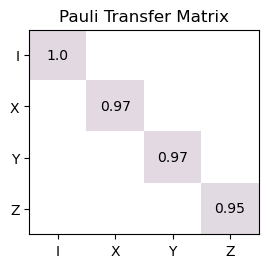

In [14]:
effective_dressed_cycle_noise(Gate.t, Gate.cliff8, noisy_gates)

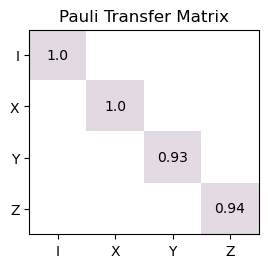

In [15]:
effective_dressed_cycle_noise(Gate.h, Gate.z, noisy_gates)

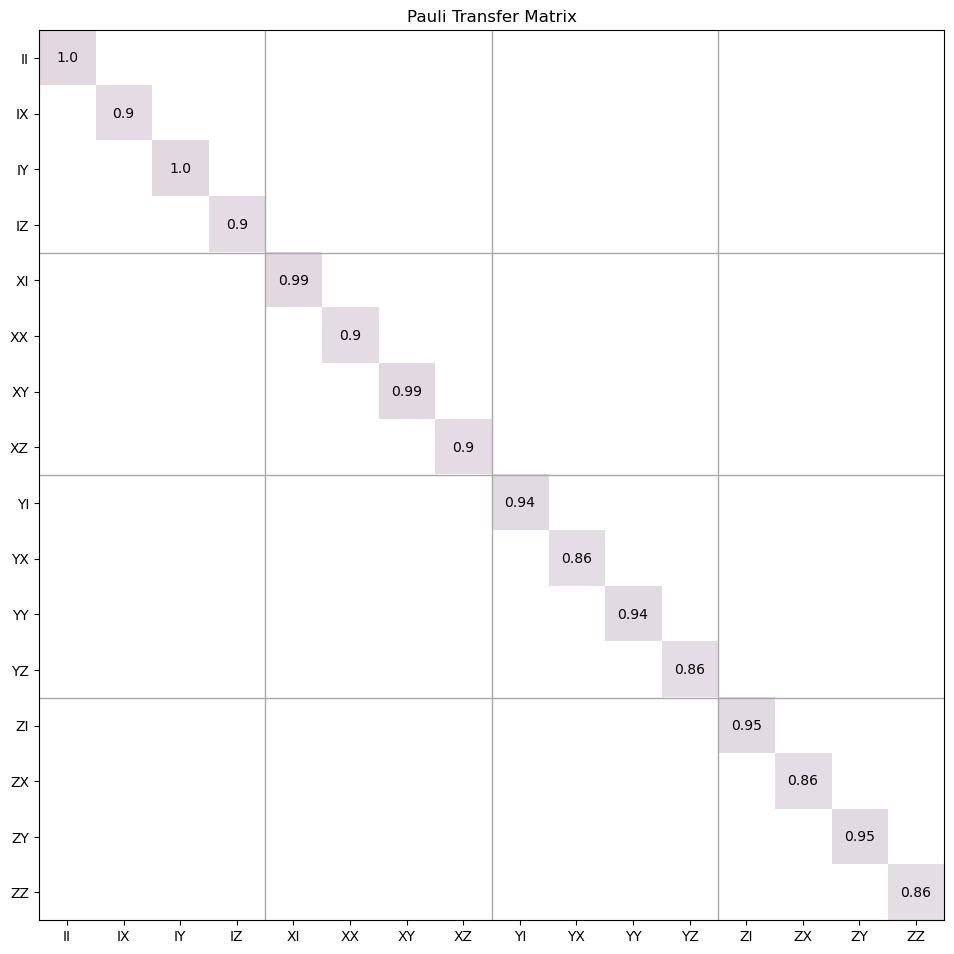

In [16]:
effective_dressed_cycle_noise(Gate.cx, two_q_easy_gates[(Gate.x,Gate.s)], noisy_gates)